In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

/tmp
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/numpy
/usr/share/zoneinfo
/home/flavia/.config/matplotlib
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data


/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/.config/matplotlib
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/scipy


This notebook analyses the behaviour of NO2 pollutant in the neighbourhood Barcelona Sants. The data are from Barcelona Open Data portal. 
1) Open data and metadata and check the dataframe shape, the information stored and the codes corresponding to the desired place and pollutant.
2) Select the data to analyse and reshape the dataset (wide -> long). 
3) Build timestamps and set the datetime as index
4) First NaNs handling (drop them)
5) Define and evaluate baseline.

Evaluate metadata

In [2]:
md_contaminants = pd.read_csv('../data/qualitat_aire_contaminants.csv')
md_stations = pd.read_csv('../data/2025_qualitat_aire_estacions.csv')
md_stations['Estacio'].unique()

array([ 4, 42, 43, 44, 50, 54, 57, 58])

In [3]:
md_42 = md_stations[md_stations['Estacio'] == 42]
md_42.head()

,Estacio,nom_cabina,codi_dtes,zqa,codi_eoi,Longitud,Latitud,ubicacio,Codi_districte,Nom_districte,Codi_barri,Nom_barri,Clas_1,Clas_2,Codi_Contaminant
4,42,Barcelona - Sants,ID,1,8019042,2.1331,41.3788,Jardins de Can Mantega (Joan Güell - Violant d...,3,Sants-Montjuic,18,Sants,Urbana,Fons,8
5,42,Barcelona - Sants,ID,1,8019042,2.1331,41.3788,Jardins de Can Mantega (Joan Güell - Violant d...,3,Sants-Montjuic,18,Sants,Urbana,Fons,7
6,42,Barcelona - Sants,ID,1,8019042,2.1331,41.3788,Jardins de Can Mantega (Joan Güell - Violant d...,3,Sants-Montjuic,18,Sants,Urbana,Fons,12


The dataset encodes pollutants using numeric identifiers. According to the official metadata provided by Barcelona Open Data, code 8 corresponds to Nitrogen Dioxide (NO2), which was selected for this analysis due to its relevance to urban air quality and health.

open and check dataset

In [4]:
df = pd.read_csv("../data/air_quality.csv")
df.head()

,CODI_PROVINCIA,PROVINCIA,CODI_MUNICIPI,MUNICIPI,ESTACIO,CODI_CONTAMINANT,ANY,MES,DIA,H01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
0,8,Barcelona,19,Barcelona,43,999,2026,1,18,19.2,...,21.7,V,25.7,V,26.0,V,25.7,V,26.3,V
1,8,Barcelona,19,Barcelona,43,999,2026,1,19,22.6,...,22.4,V,19.2,V,13.7,V,19.1,V,21.0,V
2,8,Barcelona,19,Barcelona,43,999,2026,1,20,24.5,...,21.0,V,18.8,V,20.9,V,19.7,V,22.7,V
3,8,Barcelona,19,Barcelona,43,999,2026,1,21,23.4,...,NaN,N,NaN,N,NaN,N,NaN,N,NaN,N
4,8,Barcelona,19,Barcelona,54,999,2026,1,18,27.0,...,25.4,V,23.6,V,23.6,V,29.8,V,28.0,V


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 57 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CODI_PROVINCIA    316 non-null    int64  
 1   PROVINCIA         316 non-null    object 
 2   CODI_MUNICIPI     316 non-null    int64  
 3   MUNICIPI          316 non-null    object 
 4   ESTACIO           316 non-null    int64  
 5   CODI_CONTAMINANT  316 non-null    int64  
 6   ANY               316 non-null    int64  
 7   MES               316 non-null    int64  
 8   DIA               316 non-null    int64  
 9   H01               312 non-null    float64
 10  V01               316 non-null    object 
 11  H02               312 non-null    float64
 12  V02               316 non-null    object 
 13  H03               312 non-null    float64
 14  V03               316 non-null    object 
 15  H04               312 non-null    float64
 16  V04               316 non-null    object 
 1

,CODI_PROVINCIA,CODI_MUNICIPI,ESTACIO,CODI_CONTAMINANT,ANY,MES,DIA,H01,H02,H03,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
count,316.0,316.0,316.000000,316.000000,316.0,316.0,316.000000,312.000000,312.000000,312.00000,...,311.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000
mean,8.0,19.0,143.430380,180.696203,2026.0,1.0,19.500000,282.107083,278.087532,276.69875,...,298.837428,295.223077,294.901880,298.306880,299.552521,296.590128,291.151068,291.451709,286.824658,285.904359
std,0.0,0.0,265.149383,357.888246,0.0,0.0,1.119807,1001.283850,1001.503853,1001.58492,...,1008.812675,1007.181315,1005.836582,1007.922424,1007.896011,1005.569131,1003.874757,1004.034117,1002.075866,1002.247690
min,8.0,19.0,4.000000,1.000000,2026.0,1.0,18.000000,0.000000,0.000000,-0.02000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.020000,0.000000,0.000000,-0.030000
25%,8.0,19.0,43.000000,8.000000,2026.0,1.0,18.750000,2.112500,2.000000,1.00000,...,2.000000,3.000000,3.000000,3.000000,3.235000,4.000000,2.307500,3.000000,3.000000,3.000000
50%,8.0,19.0,54.000000,11.000000,2026.0,1.0,19.500000,8.300000,6.000000,5.81500,...,13.000000,10.850000,12.000000,12.000000,12.855000,11.005000,12.000000,10.000000,10.000000,9.000000
75%,8.0,19.0,57.000000,107.000000,2026.0,1.0,20.250000,28.325000,32.175000,29.65000,...,38.000000,37.500000,36.750000,37.500000,36.750000,36.000000,27.000000,36.000000,34.250000,32.775000
max,8.0,19.0,881.000000,999.000000,2026.0,1.0,21.000000,4999.000000,4999.000000,4999.00000,...,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000


Identify NO2 and select the relevant column. Identify a station (This case is Barcelona Sants)

In [6]:
df.columns

Index(['CODI_PROVINCIA', 'PROVINCIA', 'CODI_MUNICIPI', 'MUNICIPI', 'ESTACIO',
       'CODI_CONTAMINANT', 'ANY', 'MES', 'DIA', 'H01', 'V01', 'H02', 'V02',
       'H03', 'V03', 'H04', 'V04', 'H05', 'V05', 'H06', 'V06', 'H07', 'V07',
       'H08', 'V08', 'H09', 'V09', 'H10', 'V10', 'H11', 'V11', 'H12', 'V12',
       'H13', 'V13', 'H14', 'V14', 'H15', 'V15', 'H16', 'V16', 'H17', 'V17',
       'H18', 'V18', 'H19', 'V19', 'H20', 'V20', 'H21', 'V21', 'H22', 'V22',
       'H23', 'V23', 'H24', 'V24'],
      dtype='object')

In [7]:
df['CODI_CONTAMINANT'].unique()

array([999,  22,   6, 106, 997, 996, 998,   7, 107,   8, 108,  12, 112,
       995,  14, 114,  11, 111,  10, 110,   9, 109, 901,   1, 101])

In [8]:
df['ESTACIO'].unique()

array([ 43,  54,  57,  50,  44,  58,   4,  42, 881])

In [9]:
df_no2 = df[df['CODI_CONTAMINANT'] == 8]
df_station = df_no2[df_no2['ESTACIO'] == 42]
df_station.head()

,CODI_PROVINCIA,PROVINCIA,CODI_MUNICIPI,MUNICIPI,ESTACIO,CODI_CONTAMINANT,ANY,MES,DIA,H01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
120,8,Barcelona,19,Barcelona,42,8,2026,1,18,18.0,...,28.0,V,19.0,V,17.0,V,15.0,V,16.0,V
121,8,Barcelona,19,Barcelona,42,8,2026,1,19,18.0,...,25.0,V,22.0,V,17.0,V,11.0,V,8.0,V
122,8,Barcelona,19,Barcelona,42,8,2026,1,20,6.0,...,24.0,V,20.0,V,20.0,V,24.0,V,17.0,V
123,8,Barcelona,19,Barcelona,42,8,2026,1,21,13.0,...,NaN,N,NaN,N,NaN,N,NaN,N,NaN,N


reshape the dataset, build time index and carry the correct flags for the measurements

In [10]:
# Wide -> long for NO₂ values and their per-hour validation flags

value_cols = [f'H{i:02d}' for i in range(1, 25)]
flag_cols  = [f'V{i:02d}' for i in range(1, 25)]

# 1) Melt values (H01..H24)
df_values = df_station.melt(
    id_vars=['ANY', 'MES', 'DIA', 'ESTACIO'],
    value_vars=value_cols,
    var_name='hour',
    value_name='NO2'
)
df_values['hour'] = df_values['hour'].str[1:].astype(int) - 1  # H01->0, ..., H24->23

# 2) Melt flags (V01..V24)
df_flags = df_station.melt(
    id_vars=['ANY', 'MES', 'DIA', 'ESTACIO'],
    value_vars=flag_cols,
    var_name='hour_flag',
    value_name='valid_flag'
)
df_flags['hour'] = df_flags['hour_flag'].str[1:].astype(int) - 1

# 3) Merge to keep correct alignment between value and flag
df_long = df_values.merge(
    df_flags[['ANY', 'MES', 'DIA', 'ESTACIO', 'hour', 'valid_flag']],
    on=['ANY', 'MES', 'DIA', 'ESTACIO', 'hour'],
    how='left'
)

# 4) Build timestamp
df_long['datetime'] = pd.to_datetime(
    dict(
        year=df_long['ANY'],
        month=df_long['MES'],
        day=df_long['DIA'],
        hour=df_long['hour']
    )
)

# 5) Create cleaned target (invalid -> NaN)
df_long['NO2_clean'] = df_long['NO2'].where(df_long['valid_flag'] == 'V')

# 6) Keep tidy columns for analysis/modeling
df_long = (df_long[['datetime', 'ESTACIO', 'NO2', 'NO2_clean', 'valid_flag']]
           .rename(columns={'ESTACIO': 'station'})
           .sort_values('datetime')
           .reset_index(drop=True))

df_long.tail()


,datetime,station,NO2,NO2_clean,valid_flag
91,2026-01-21 19:00:00,42,NaN,NaN,N
92,2026-01-21 20:00:00,42,NaN,NaN,N
93,2026-01-21 21:00:00,42,NaN,NaN,N
94,2026-01-21 22:00:00,42,NaN,NaN,N
95,2026-01-21 23:00:00,42,NaN,NaN,N


In [11]:
#sanity check
print(df_long[['valid_flag', 'NO2']].to_string(index=True))
print(df_long[['valid_flag', 'NO2_clean']].to_string(index=True))

   valid_flag   NO2
0           V  18.0
1           V  15.0
2           V  17.0
3           V  27.0
4           V  29.0
5           V  22.0
6           V  21.0
7           V  24.0
8           V  30.0
9           V  29.0
10          V  20.0
11          V  25.0
12          V  21.0
13          V  18.0
14          V  20.0
15          V  18.0
16          V  18.0
17          V  21.0
18          V  25.0
19          V  28.0
20          V  19.0
21          V  17.0
22          V  15.0
23          V  16.0
24          V  18.0
25          V  12.0
26          V  11.0
27          V   9.0
28          V   8.0
29          V  13.0
30          V  16.0
31          V  29.0
32          V  40.0
33          V  41.0
34          V  40.0
35          V  34.0
36          V  23.0
37          V  21.0
38          V  19.0
39          V  20.0
40          V  23.0
41          V  30.0
42          V  29.0
43          V  25.0
44          V  22.0
45          V  17.0
46          V  11.0
47          V   8.0
48          V   6.0


Plot NO2 concentration in Sants in January 2025

/
/home
/home/flavia
/home/flavia/anaconda3
/home/flavia/anaconda3/envs
/home/flavia/anaconda3/envs/astroconda
/home/flavia/anaconda3/envs/astroconda/lib
/home/flavia/anaconda3/envs/astroconda/lib/python3.7
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data/fonts
/home/flavia/anaconda3/envs/astroconda/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf


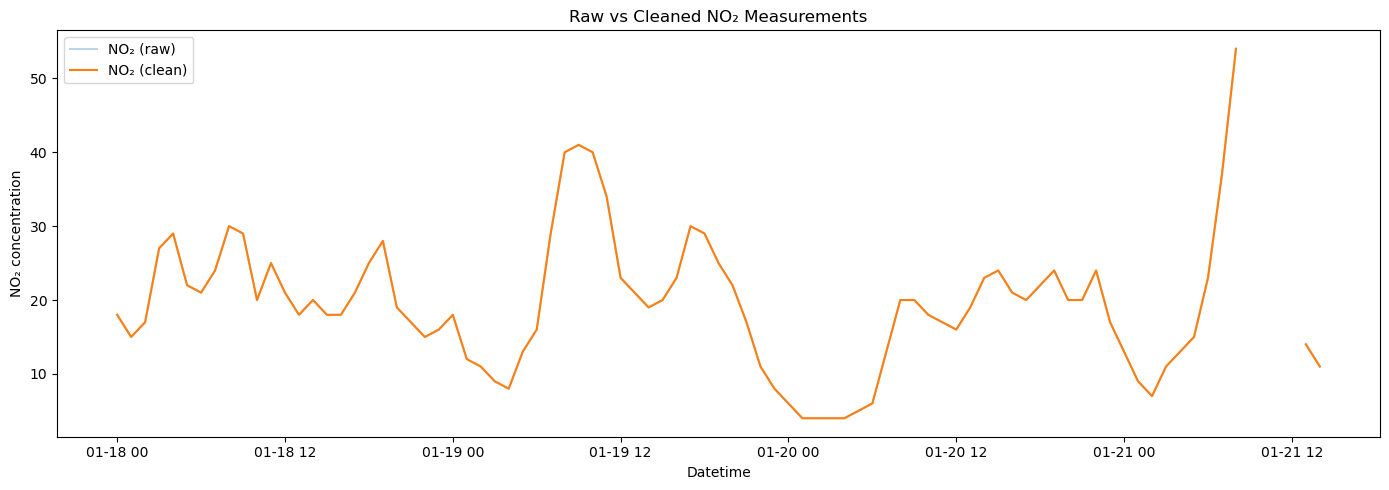

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_long['datetime'],
    df_long['NO2'],
    label='NO₂ (raw)',
    alpha=0.3
)

plt.plot(
    df_long['datetime'],
    df_long['NO2_clean'],
    label='NO₂ (clean)',
    linewidth=1.5
)

plt.xlabel('Datetime')
plt.ylabel('NO₂ concentration')
plt.title('Raw vs Cleaned NO₂ Measurements')
plt.legend()

plt.tight_layout()
plt.show()

### Validation of cleaning step

The comparison between raw and cleaned NO₂ measurements shows that the cleaning
procedure removes a limited number of invalid observations without altering
the overall temporal structure of the signal. This confirms that the dataset
is suitable for time-series analysis and forecasting.

Set datetime as index

In [13]:
df_long = df_long.set_index('datetime').sort_index()

Check frequency and gaps

In [14]:
df_long.index.inferred_freq

'H'

check missing values

In [15]:
df_long[['NO2_clean']].isna().sum()

NO2_clean    13
dtype: int64

Handling NaNs: Dropping the rows with NaNs is now a safe choice

In [16]:
df_model = df_long.dropna(subset=['NO2_clean']).copy()

define baselines, persistance and seasonal

In [17]:
df_model['pred_persistence'] = df_model['NO2_clean'].shift(1)
df_model['pred_seasonal_24h'] = df_model['NO2_clean'].shift(24)


define test train split

In [18]:
split_idx = int(len(df_model) * 0.8)

train = df_model.iloc[:split_idx].copy()
test  = df_model.iloc[split_idx:].copy()

In [19]:
test_eval = test.dropna(
    subset=['NO2_clean', 'pred_persistence', 'pred_seasonal_24h']
)


In [20]:
y_true = test_eval['NO2_clean']

calculate MAE and RMSE for both baselines

In [21]:
mae_p = mean_absolute_error(y_true, test_eval['pred_persistence'])
rmse_p = np.sqrt(mean_squared_error(y_true, test_eval['pred_persistence']))

mae_s = mean_absolute_error(y_true, test_eval['pred_seasonal_24h'])
rmse_s = np.sqrt(mean_squared_error(y_true, test_eval['pred_seasonal_24h']))



In [22]:
print(f'Persistence — MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}')
print(f'Seasonal 24h — MAE: {mae_s:.2f}, RMSE: {rmse_s:.2f}')


Persistence — MAE: 7.00, RMSE: 11.65
Seasonal 24h — MAE: 9.65, RMSE: 12.68


Plot baselines with data

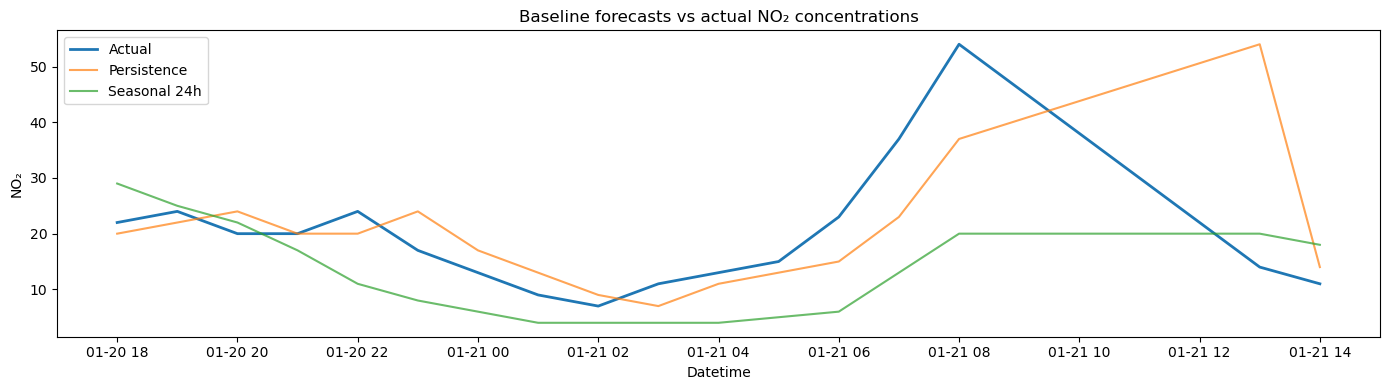

In [23]:
plt.figure(figsize=(14, 4))

plt.plot(test_eval.index, y_true, label='Actual', linewidth=2)
plt.plot(test_eval.index, test_eval['pred_persistence'],
         label='Persistence', alpha=0.7)
plt.plot(test_eval.index, test_eval['pred_seasonal_24h'],
         label='Seasonal 24h', alpha=0.7)

plt.title('Baseline forecasts vs actual NO₂ concentrations')
plt.xlabel('Datetime')
plt.ylabel('NO₂')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
baseline_results = pd.DataFrame({
    'Model': ['Persistence', 'Seasonal naive (24h)'],
    'MAE': [mae_p, mae_s],
    'RMSE': [rmse_p, rmse_s]
})

baseline_results

,Model,MAE,RMSE
0,Persistence,7.000000,11.649287
1,Seasonal naive (24h),9.647059,12.676982
